# Understanding the Roman WFI Flat Reference File 

## Kernel Information and Read-Only Status

To run this notebook, please select "Roman Research Nexus {VERSION}" kernel at the top right of your window. For example "Roman Research Nexus 2026.2".

This notebook is read-only. You can run cells and make edits, but you must save changes to a different location. We recommend saving the notebook within your home directory, or to a new folder within your home (e.g. <span style="font-variant:small-caps;">file > save notebook as > my-nbs/nb.ipynb</span>). Note that a directory must exist before you attempt to add a notebook to it.
    

## Introduction
The purpose of this notebook is to understand the the content and purpose of the **Flat** (`FLAT`) reference file.

More details about this and other reference files can be found in the [Reference File Information](https://roman-pipeline.readthedocs.io/en/stable/roman/references_general/index.html)

### Local Run Settings

If you want to run the notebook in your local machine, refer to the information in [local installation](../../markdown/local-run.md) instructions before proceeding with the notebook. The instructions provide inportant information about setting up your environment and installing dependnecies.

## Imports
Libraries used:
- *astropy* for image normalization
- *copy* for making copies of Python objects
- *crds* for access to calibration reference files
- *matplotlib* and *mpl_toolkits* for plotting images
- *numpy* for array manipulation
- *os* for operating system functions

In [1]:
import os
from astropy.visualization import simple_norm
import copy

import matplotlib.pyplot as plt
from matplotlib import colors, colormaps as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import roman_datamodels as rdm

### The Calibration Reference Data System (CRDS)

The reference files, developed and validated by STScI’s Science Operations Center, are continually updated as new WFI data become available. For more information about how CRDS works and how it assigns the most appropriate reference file for each calibration step, refer to the notebook [Inderstanding CRDS and How to Select Calibration Reference files](crds_reference_files.ipynb). 

**IMPORTANT NOTE:** Reference files are a work in progress and will be updated several times before Roman launch. If you notice irregularities or missing information, please understand that they may be a known issue. If you have questions, please contact the [Roman Help Desk](https://romanhelp.stsci.edu).

In [2]:
import crds

Now let's dive into this reference file.

### Flats

The FLAT reference file is selected based on the optical element used to obtain the science data.  It contains the flatfield data which corrects for pixel-to-pixel sensitivity variations across the detector, ensuring uniform data for a specific imaging filter.  During the `flat_field` step, the science array is divided by the flatfield reference array for the matching filter, effectively "flattening" the variations in the data.  Pixels with negative values or that are flagged will be skipped and not updated.

The flat reference file is created from flat calibration datasets.  A set of flat exposures with the same filter within some date range to the science data are used to compute flat rate images. These are averaged together and normalized, producing a filter-dependent flat rate image. Spectroscopic mode observations are not flatfielded by RomanCal, and there are no flat reference files available for the WFI grism or prism available from the Science Operations Center at STScI. For grism and prism observations, the flatfield step will be skipped.

For more details, see the [romancal documentation](https://roman-pipeline.readthedocs.io/en/latest/roman/flatfield/index.html) and [Rdox documentation](https://roman-docs.stsci.edu/data-handbook-home/roman-data-pipelines/exposure-level-pipeline#ExposureLevelPipeline-flatfield) for flat fielding.


Let's check the environmental variables set for CRDS

In [3]:
print(f"CRDS server location: {os.environ.get('CRDS_SERVER_URL')}")
print(f"CRDS context file: {os.environ.get('CRDS_CONTEXT')}")

CRDS server location: https://roman-crds.stsci.edu
CRDS context file: roman-edit


If we want to change the context, we can do it in the next cell. In this case, we choose context `roman_0055.pmap`.

In [4]:
os.environ['CRDS_CONTEXT']='roman_0055.pmap'

### Retrieving Reference Files

As you run the exposure pipeline, the most up-to-date reference files will be automatically selected for each step. However, if you would like to use a specific reference file, retrieve those from `crds` Python API and feed these to the Exposure Level Pipeline, see the notebook [Understanding CRDS and How to Select Calibration Reference files](crds_reference_files.ipynb) for more details. 

For the flat files in particular, the keywords that will identify the best reference file to use are:

- ROMAN.META.INSTRUMENT.NAME
- ROMAN.META.INSTRUMENT.DETECTOR
- ROMAN.META.INSTRUMENT.OPTICAL_ELEMENT
- ROMAN.META.EXPOSURE.START_TIME

These keywords may be combined into a single dictionary to find and download the file using `crds.getreferences()`.  

In [5]:
meta = {'ROMAN.META.INSTRUMENT.NAME': 'WFI',
        'ROMAN.META.INSTRUMENT.DETECTOR': 'WFI01',
        'ROMAN.META.INSTRUMENT.OPTICAL_ELEMENT': 'F158',
        'ROMAN.META.EXPOSURE.TYPE': 'WFI_IMAGE',
        'ROMAN.META.EXPOSURE.START_TIME': '2026-01-01 00:00:00'
       }

ref_files = crds.getreferences(meta, reftypes=['flat'], observatory='roman')
ref_files

{'flat': '/home/runner/crds_cache/references/roman/wfi/roman_wfi_flat_0166.asdf'}

### Examining Reference Files

Reference files use `roman_datamodels` just like WFI science data products and can be accessed in the same way (see the tutorial [Working with ASDF](../working_with_asdf/working_with_asdf.ipynb) for more information). Let's take a closer look at the files we retrieved from our `crds.getreferences()` example starting with the flat file:

In [6]:
flat = rdm.open(ref_files['flat'])
flat.info()

root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): The ASDF Developers
│ ├─homepage (str): http://github.com/asdf-format/asdf
│ ├─name (str): asdf
│ └─version (str): 3.5.0
├─history (AsdfDictNode)
│ └─extensions (AsdfListNode)
│   ├─0 (ExtensionMetadata) ...
│   └─1 (ExtensionMetadata) ...
└─roman (FlatRef) # Flat Reference File Schema
  ├─meta (AsdfDictNode)
  │ ├─author (str): Richard G Cosentino # Author
  │ ├─description (str): Flat reference file using TVAC2 data using CFA data from sRCS LED band 5, combining (truncated)
  │ ├─instrument (AsdfDictNode) ...
  │ ├─origin (Origin): STSCI # Institution / Organization Name
  │ ├─pedigree (str): GROUND # Pedigree
  │ ├─reftype (str): FLAT
  │ ├─telescope (Telescope): ROMAN # Telescope Name
  │ └─useafter (Time): 2023-08-01T00:00:00.000 # Use After Date
  ├─data (NDArrayType) # Flat Data Array ...
  ├─dq (NDArrayType) # 2-D Data Quality Array ...
  └─err (NDArrayType) # Flat Data Uncertainty Array ...
Some nodes not shown.


Once again, we see a `data` array, which in this case is the flatfield values, a `dq` array for flagging effects in the flatfield, and an `error` array. Let's take a look at the flatfield for this detector:

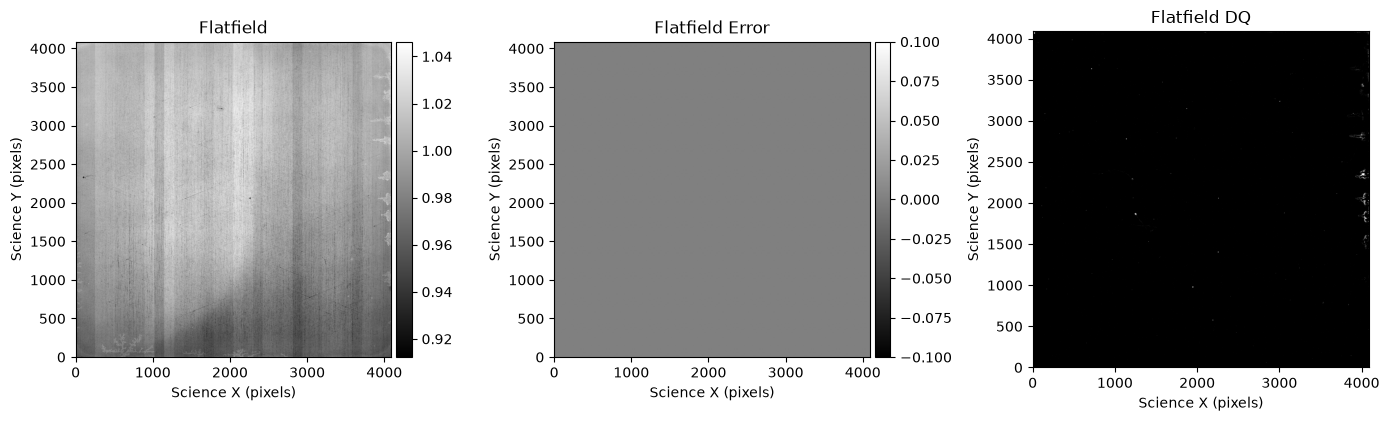

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(14, 14))

norm = simple_norm(flat.data, percent=99.5)
data = axs[0].imshow(flat.data, cmap='gray', norm=norm, origin='lower')
axs[0].set_xlabel('Science X (pixels)')
axs[0].set_ylabel('Science Y (pixels)')
axs[0].set_title('Flatfield')
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(data, cax=cax)

norm = simple_norm(flat.err, percent=99.5)
err = axs[1].imshow(flat.err, cmap='gray', norm=norm, origin='lower')
axs[1].set_xlabel('Science X (pixels)')
axs[1].set_ylabel('Science Y (pixels)')
axs[1].set_title('Flatfield Error')
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(err, cax=cax)

axs[2].imshow(np.bool(flat.dq), cmap='binary_r', origin='lower')
axs[2].set_xlabel('Science X (pixels)')
axs[2].set_ylabel('Science Y (pixels)')
axs[2].set_title('Flatfield DQ')

plt.tight_layout();

## About this Notebook
**Author:** R. Diaz & T. Desjardins

**Updated On:** 2026-07-06

<table width="100%" style="border:none; border-collapse:collapse;">

  <tr style="border:none;">
    <td style="border:none; width:180px; white-space:nowrap;">
       <a href="#top" style="text-decoration:none; color:#0066cc;"> Top of page</a>
    </td>
    <td style="border:none; text-align:center;">
        <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/roman_logo.png" alt="roman_logo" width="50px">
    </td>
    <td style="border:none; text-align:right;">
       <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/stsci_logo2.png" width="90">
    </td>
  </tr>
</table>